In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [17]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("covid19_global_statistics_2026.csv")
df.head(-1)

,continent,country,population,date,new_cases,active_cases,cases_per_million,total_cases,new_deaths,deaths_per_million,total_deaths,tests_per_million,total_tests
0,Africa,Eritrea,3662244.0,2026-02-16,NaN,0.0,2782.0,10189,NaN,28.0,103.0,6470.0,23693.0
1,Africa,Niger,26083660.0,2026-02-16,NaN,729.0,381.0,9931,NaN,12.0,312.0,9759.0,254538.0
2,Africa,Saint-Helena,6115.0,2026-02-16,NaN,2164.0,354211.0,2166,NaN,NaN,NaN,NaN,NaN
3,South-America,Falkland-Islands,3539.0,2026-02-16,NaN,0.0,545352.0,1930,NaN,NaN,NaN,2439107.0,8632.0
4,North-America,Montserrat,4965.0,2026-02-16,NaN,19.0,282578.0,1403,NaN,1611.0,8.0,3577442.0,17762.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Europe,Italy,60262770.0,2026-02-16,NaN,165544.0,443445.0,26723249,NaN,3261.0,196487.0,4665010.0,281126449.0
233,Europe,UK,68497907.0,2026-02-16,NaN,0.0,363666.0,24910387,NaN,3389.0,232112.0,7628357.0,522526476.0
234,Europe,Russia,145805947.0,2026-02-16,NaN,175641.0,165454.0,24124215,NaN,2762.0,402756.0,1875095.0,273400000.0
235,Asia,Turkey,85561976.0,2026-02-16,NaN,NaN,201399.0,17232066,NaN,1194.0,102174.0,1902052.0,162743369.0


## Task 1
### data quality issues:
- **Issue 1**
   The continent field is missing for certain entities like cruise ships
- **Issue 2**
    Numerical features like population and total_cases have massive ranges (from thousands to billions), which can dominate models if not normalized
- **Issue 3**
    The columns new_cases and new_deaths are missing over 90% of their data (only 17 and 3 not null values respectively)

## Task 2
### missing Value strategy:

In [18]:
# Check for missing values in the dataset
print(df.isnull().sum())

continent               2
country                 0
population              9
date                    0
new_cases             221
active_cases           47
cases_per_million       8
total_cases             0
new_deaths            235
deaths_per_million     13
total_deaths            5
tests_per_million      25
total_tests            25
dtype: int64


In [29]:
# This ensures the median is calculated based on country-level data only.
exclude_list = ['All', 'North-America', 'Asia', 'Europe', 'South-America', 'Oceania', 'Africa']
df_countries = df[~ df['country'].isin(exclude_list)].copy()

# Identify numerical columns
# This selects columns like 'population', 'active_cases', 'total_deaths'
numerical_columns = df_countries.select_dtypes(include=[np.number]).columns

# Apply Median Imputation
# We iterate through each numerical column and fill NaNs with the median
for col in numerical_columns:
    median_val = df_countries[col].median()
    df_countries[col] = df_countries[col].fillna(median_val)
    
# Verify results
print("Missing values after imputation:")
print(df_countries.isnull().sum())


Missing values after imputation:
continent             2
country               0
population            0
date                  0
new_cases             0
active_cases          0
cases_per_million     0
total_cases           0
new_deaths            0
deaths_per_million    0
total_deaths          0
tests_per_million     0
total_tests           0
dtype: int64


I specifically targeted numerical columns like active_cases, total_deaths, population and used .median() on them to ensure that if there is a missing value it is filled with the global median to not being affected by the extreme outlieres like the USA and India 

## Task 3
###  Using IQR

In [34]:
# Define the function to handle outliers using the IQR method
def handle_outliers(df, column):
    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate the IQR
    IQR = Q3 - Q1
    
    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"Processing column: {column}")
    print(f"  - Q1: {Q1:,.2f}, Q3: {Q3:,.2f}, IQR: {IQR:,.2f}")
    print(f"  - Lower Bound: {lower_bound:,.2f}")
    print(f"  - Upper Bound: {upper_bound:,.2f}")
    
    # Apply Capping: 
    # Replace values below the lower bound with the lower bound
    # Replace values above the upper bound with the upper bound
    df[column] = np.where(df[column] < lower_bound, lower_bound, 
                 np.where(df[column] > upper_bound, upper_bound, df[column]))
    
    print(f"  - Outliers in '{column}' have been capped.\n")
    return df

# Select the numerical columns to check for outliers
cols_to_fix = ['total_cases', 'population', 'total_deaths']

# Apply the function to the dataset
for col in cols_to_fix:
    df_countries = handle_outliers_iqr(df_countries, col)

Processing column: total_cases
  - Q1: 26,366.00, Q3: 1,348,198.50, IQR: 1,321,832.50
  - Lower Bound: -1,956,382.75
  - Upper Bound: 3,330,947.25
  - Outliers in 'total_cases' have been capped.

Processing column: population
  - Q1: 493,208.00, Q3: 21,839,340.00, IQR: 21,346,132.00
  - Lower Bound: -31,525,990.00
  - Upper Bound: 53,858,538.00
  - Outliers in 'population' have been capped.

Processing column: total_deaths
  - Q1: 225.00, Q3: 14,287.00, IQR: 14,062.00
  - Lower Bound: -20,868.00
  - Upper Bound: 35,380.00
  - Outliers in 'total_deaths' have been capped.



In [35]:
# Check the statistics to verify the maximum values are now capped
print(df_countries[cols_to_fix].describe())

        total_cases    population  total_deaths
count  2.310000e+02  2.310000e+02    231.000000
mean   9.235368e+05  1.480597e+07   9316.417749
std    1.249463e+06  1.862688e+07  12740.777597
min    9.000000e+00  7.990000e+02      1.000000
25%    2.636600e+04  4.932080e+05    225.000000
50%    2.068970e+05  5.797805e+06   2204.500000
75%    1.348198e+06  2.183934e+07  14287.000000
max    3.330947e+06  5.385854e+07  35380.000000


## Task 4
### Normalize numerical features using both Min-Max and Z-score

In [36]:
import pandas as pd
import numpy as np

# 1. Define the features to normalize
features = ['population', 'active_cases', 'cases_per_million', 'total_cases', 'total_deaths', 'total_tests']

# Min-Max Scaling
# Formula: (X - min) / (max - min)
# This scales all values strictly between 0 and 1
df_min_max = df_countries.copy()
df_min_max[features] = (df_countries[features] - df_countries[features].min()) / \
                       (df_countries[features].max() - df_countries[features].min())

In [37]:

# Z-Score Normalization (Standardization)
# Formula: (X - mean) / standard_deviation
# This centers the data around 0 with a standard deviation of 1
df_z_score = df_countries.copy()
df_z_score[features] = (df_countries[features] - df_countries[features].mean()) / \
                       (df_countries[features].std())

In [46]:
# Verify results
print("Min-Max Result:")
print(df_min_max[features])

Min-Max Result:
     population  active_cases  cases_per_million  total_cases  total_deaths  \
0      0.067984      0.000000           0.003585     0.003056      0.002883   
1      0.484292      0.000409           0.000473     0.002979      0.008791   
2      0.000099      0.001213           0.459016     0.000648      0.062283   
3      0.000051      0.000000           0.706724     0.000577      0.062283   
4      0.000077      0.000011           0.366184     0.000419      0.000198   
..          ...           ...                ...          ...           ...   
233    1.000000      0.000000           0.471270     1.000000      1.000000   
234    1.000000      0.098488           0.214398     1.000000      1.000000   
235    1.000000      0.000302           0.260981     1.000000      1.000000   
236    0.484016      0.004887           0.589228     1.000000      0.690042   
237    1.000000      0.527661           0.152228     1.000000      1.000000   

      total_tests  
0    1.334885e-

In [47]:
print("Z-Score Result:")
print(df_z_score[features])

Z-Score Result:
     population  active_cases  cases_per_million  total_cases  total_deaths  \
0     -0.598260     -0.179415          -0.971538    -0.730992     -0.723144   
1      0.605453     -0.174495          -0.983229    -0.731199     -0.706740   
2     -0.794543     -0.164811           0.739645    -0.737413     -0.558201   
3     -0.794681     -0.179415           1.670352    -0.737602     -0.558201   
4     -0.794604     -0.179287           0.390849    -0.738024     -0.730600   
..          ...           ...                ...          ...           ...   
233    2.096571     -0.179415           0.785684     1.926756      2.045682   
234    2.096571      1.005958          -0.179453     1.926756      2.045682   
235    2.096571     -0.175778          -0.004429     1.926756      2.045682   
236    0.604654     -0.120592           1.228885     1.926756      1.184981   
237    2.096571      6.171368          -0.413044     1.926756      2.045682   

     total_tests  
0      -0.264912

## Task 5
### Apply PCA and interpret explained variance

In [50]:
# Use the Z-score normalized data from Task 4
# PCA requires standardized data (mean=0, variance=1)
X = df_z_score[features].values

In [51]:
# Calculate the Covariance Matrix
# This shows how the features (population, cases, etc.) vary together
covariance_matrix = np.cov(X.T)

# Calculate Eigenvalues and Eigenvectors
# Eigenvalues = amount of variance captured , Eigenvectors = the direction of the new axes (Principal Components)
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort Eigenvalues and Eigenvectors in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [52]:
# Calculate Explained Variance Ratio
total_variance = sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

# Project the data onto the first two Principal Components
PC1 = X.dot(eigenvectors[:, 0])
PC2 = X.dot(eigenvectors[:, 1])

# Create a DataFrame for the results
df_pca = pd.DataFrame({'PC1': PC1, 'PC2': PC2})

Explained Variance by PC1: 48.28%
Explained Variance by PC2: 20.16%
Total variance captured by 2 components: 68.43%


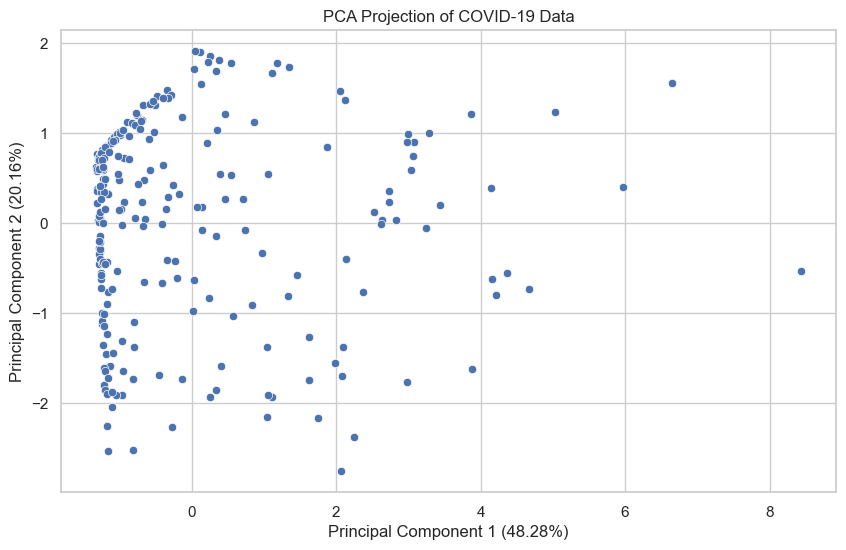

In [54]:
print(f"Explained Variance by PC1: {explained_variance_ratio[0]:.2%}")
print(f"Explained Variance by PC2: {explained_variance_ratio[1]:.2%}")
print(f"Total variance captured by 2 components: {sum(explained_variance_ratio[:2]):.2%}")

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca)
plt.title('PCA Projection of COVID-19 Data')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]:.2%})')
plt.show()